## Project 3: Multi-Sensor Visualisation Report

Simulate 4 sensor streams (temperature,
vibration, current, humidity) over 48 hours with
realistic correlations. Create a 4-panel timeseries figure, a distribution panel, and a
correlation heatmap. Save all figures to PNG
and write a matplotlib HTML report.

Skills: Matplotlib subplots, Seaborn heatmap,
figure layout, savefig

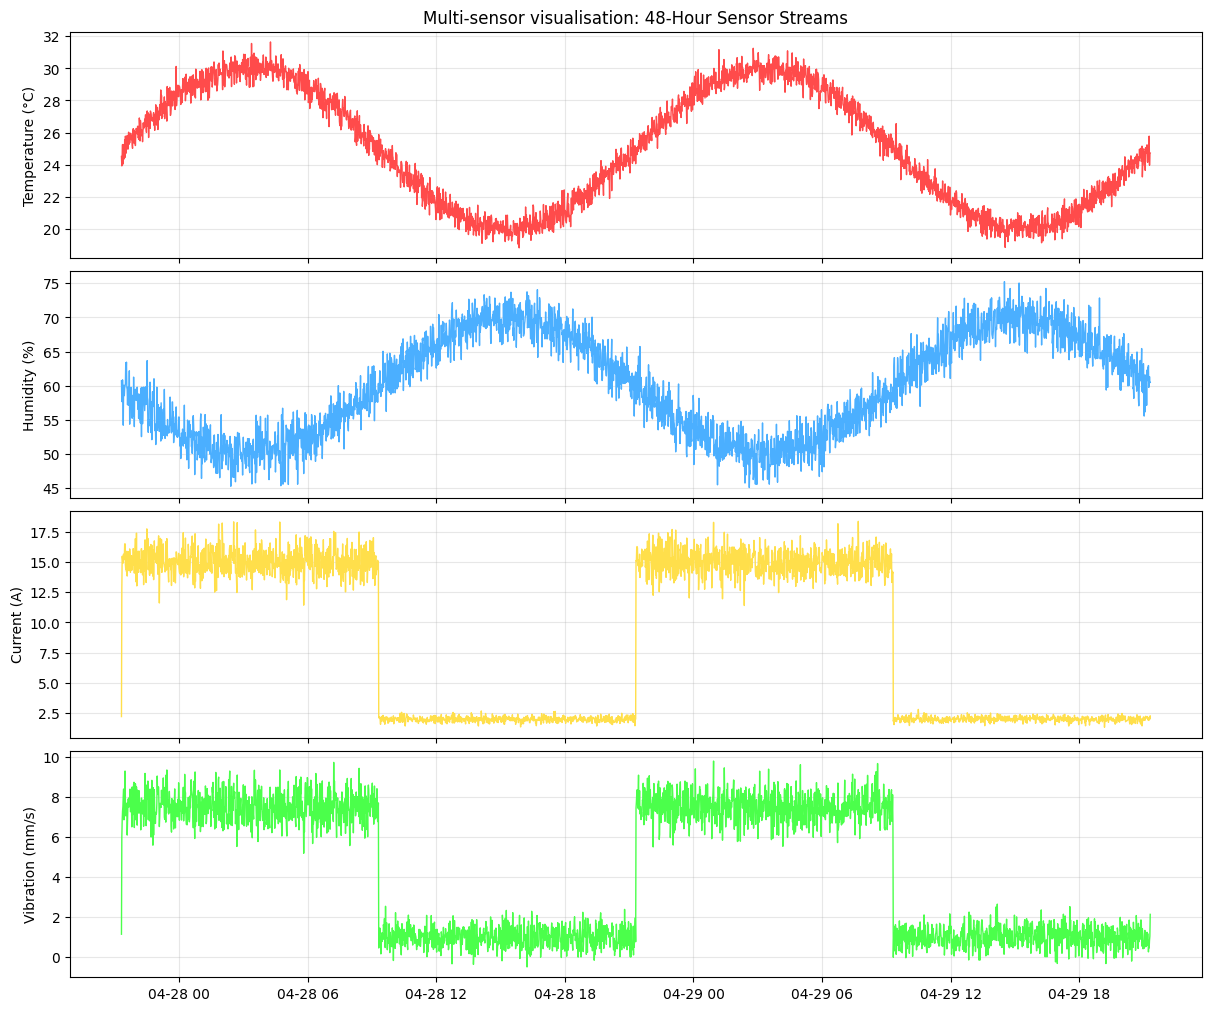

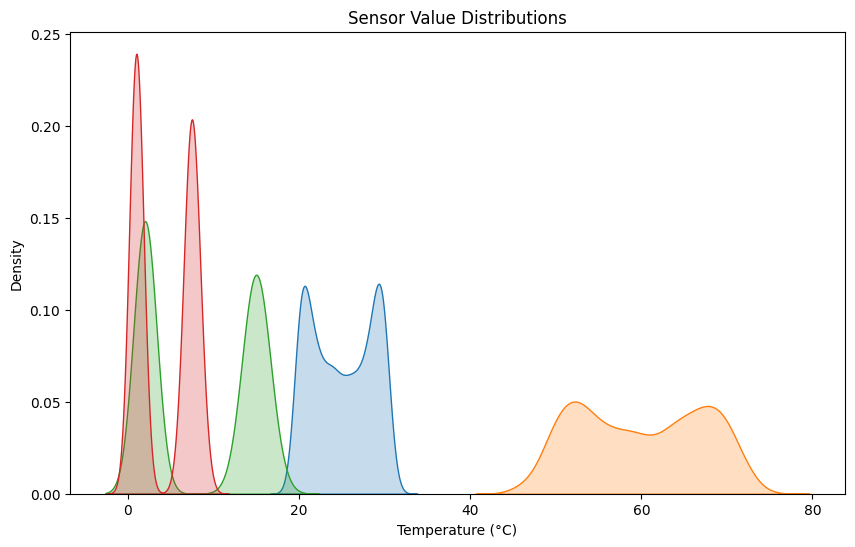

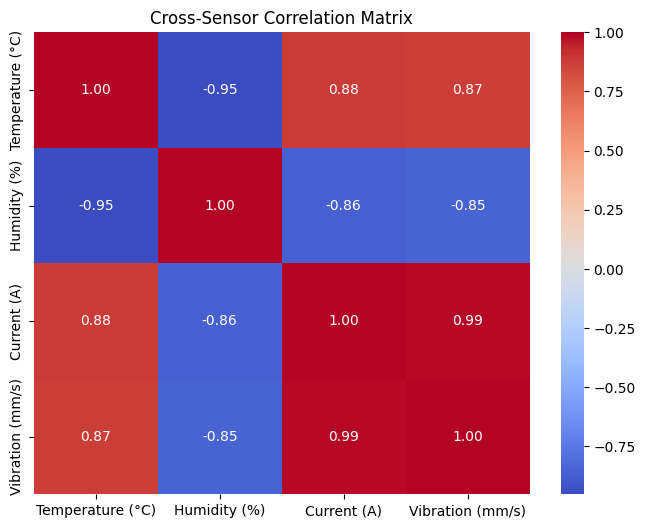

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

#plt.style.use("seaborn-vO 8-whitegrid")
#sns.set.palette("tab1O")
now=datetime.now()

# Setup time index for 48 hours
times = pd.date_range(now, periods=48*60, freq="min") # per minute
n = len(times)

# Base correlation signal (diurnal cycle)
base = np.sin(np.linspace(0, 4 * np.pi, n)) 

# Generate Sensors
temp = 25 + 5 * base + np.random.normal(0, 0.5, n)
humidity = 60 - 10 * base + np.random.normal(0, 2, n)
current = np.where(base > 0, 15 + np.random.normal(0, 1, n), 2 + np.random.normal(0, 0.2, n))
vibration = 0.5 * current + np.random.normal(0, 0.5, n)

df = pd.DataFrame({
    'Temperature (°C)': temp,
    'Humidity (%)': humidity,
    'Current (A)': current,
    'Vibration (mm/s)': vibration
}, index=times)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True, constrained_layout=True)
colors = ['#ff4b4b', '#4bafff', '#ffdf4b', '#4bff4b']

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], color=colors[i], linewidth=1)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title("Multi-sensor visualisation: 48-Hour Sensor Streams")
plt.savefig("time_series.png", dpi=300)

# Distribution Panel
plt.figure(figsize=(10, 6))
for col in df.columns:
    sns.kdeplot(df[col], fill=True, label=col)
plt.title("Sensor Value Distributions")
plt.savefig("distribution.png")

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cross-Sensor Correlation Matrix")
plt.savefig("correlation.png")

html_content = f"""
<html>
<head><title>Multi-Sensor Report</title></head>
<body style="font-family: Arial; margin: 40px;">
    <h1>Sensor Analysis Report - {datetime.now().strftime('%Y-%m-%d')}</h1>
    <hr>
    <h2>1. Temporal Analysis</h2>
    <img src="time_series.png" width="900">
    
    <h2>2. Statistical Analysis</h2>
    <div style="display: flex;">
        <img src="distribution.png" width="450">
        <img src="correlation.png" width="450">
    </div>
    
    <h3>Key Insights:</h3>
    <ul>
        <li>Vibration shows a strong positive correlation with Current.</li>
        <li>Humidity and Temperature exhibit the expected inverse diurnal relationship.</li>
    </ul>
</body>
</html>
"""

with open("report.html", "w") as f:
    f.write(html_content)